<a href="https://colab.research.google.com/github/mudassar2224/Dirichlet-Process-Mixture-Models-DPMMs-/blob/main/DPPMS_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers
!pip install umap-learn
!pip install faiss-cpu
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 73.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import ast

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import ast

from sentence_transformers import SentenceTransformer
import faiss

In [ ]:
path = "/content/drive/MyDrive/Datasets/movies/"

movies = pd.read_csv(path + "movies_metadata.csv", low_memory=False)
credits = pd.read_csv(path + "credits.csv")
keywords = pd.read_csv(path + "keywords.csv")

In [ ]:
movies.shape

(45466, 24)

In [ ]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
movies = movies[['id','title','overview','genres','vote_average','vote_count']]

In [ ]:
movies = movies.dropna(subset=['overview'])
movies

,id,title,overview,genres,vote_average,vote_count
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,34.0
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,173.0
...,...,...,...,...,...,...
45461,439050,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",4.0,1.0
45462,111109,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",9.0,3.0
45463,67758,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",3.8,6.0
45464,227506,Satan Triumphant,"In a small town live two brothers, one a minis...",[],0.0,0.0


In [ ]:
# convert to numeric, turn anything that isn’t a number into NaN
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')

# drop rows where the conversion failed
movies = movies.dropna(subset=['id'])

# now it’s safe to make it an integer
movies['id'] = movies['id'].astype(int)

# inspect
movies.head()

/tmp/ipykernel_667/1163923442.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['id'] = movies['id'].astype(int)


,id,title,overview,genres,vote_average,vote_count
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,34.0
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,173.0


In [ ]:
keywords["id"]=keywords["id"].astype(int)

In [ ]:
credits["id"]=credits["id"].astype(int)

In [ ]:
movies=movies.merge(keywords, on="id")
movies=movies.merge(credits,on="id")

In [ ]:
movies

,id,title,overview,genres,vote_average,vote_count,keywords,cast,crew
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0,"[{'id': 10090, 'name': 'board game'}, {'id': 1...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,34.0,"[{'id': 818, 'name': 'based on novel'}, {'id':...","[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,173.0,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n...","[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de..."
...,...,...,...,...,...,...,...,...,...
45628,439050,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",4.0,1.0,"[{'id': 10703, 'name': 'tragic love'}]","[{'cast_id': 0, 'character': '', 'credit_id': ...","[{'credit_id': '5894a97d925141426c00818c', 'de..."
45629,111109,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",9.0,3.0,"[{'id': 2679, 'name': 'artist'}, {'id': 14531,...","[{'cast_id': 1002, 'character': 'Sister Angela...","[{'credit_id': '52fe4af1c3a36847f81e9b15', 'de..."
45630,67758,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",3.8,6.0,[],"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","[{'credit_id': '52fe4776c3a368484e0c8387', 'de..."
45631,227506,Satan Triumphant,"In a small town live two brothers, one a minis...",[],0.0,0.0,[],"[{'cast_id': 2, 'character': '', 'credit_id': ...","[{'credit_id': '533bccebc3a36844cf0011a7', 'de..."


In [ ]:
import ast

def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

In [ ]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [ ]:
movies

,id,title,overview,genres,vote_average,vote_count,keywords,cast,crew
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[Animation, Comedy, Family]",7.7,5415.0,"[jealousy, toy, boy, friendship, friends, riva...","[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[Adventure, Fantasy, Family]",6.9,2413.0,"[board game, disappearance, based on children'...","[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[Romance, Comedy]",6.5,92.0,"[fishing, best friend, duringcreditsstinger, o...","[{'cast_id': 2, 'character': 'Max Goldman', 'c...","[{'credit_id': '52fe466a9251416c75077a89', 'de..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[Comedy, Drama, Romance]",6.1,34.0,"[based on novel, interracial relationship, sin...","[{'cast_id': 1, 'character': ""Savannah 'Vannah...","[{'credit_id': '52fe44779251416c91011acb', 'de..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,[Comedy],5.7,173.0,"[baby, midlife crisis, confidence, aging, daug...","[{'cast_id': 1, 'character': 'George Banks', '...","[{'credit_id': '52fe44959251416c75039ed7', 'de..."
...,...,...,...,...,...,...,...,...,...
45628,439050,Subdue,Rising and falling between a man and woman.,"[Drama, Family]",4.0,1.0,[tragic love],"[{'cast_id': 0, 'character': '', 'credit_id': ...","[{'credit_id': '5894a97d925141426c00818c', 'de..."
45629,111109,Century of Birthing,An artist struggles to finish his work while a...,[Drama],9.0,3.0,"[artist, play, pinoy]","[{'cast_id': 1002, 'character': 'Sister Angela...","[{'credit_id': '52fe4af1c3a36847f81e9b15', 'de..."
45630,67758,Betrayal,"When one of her hits goes wrong, a professiona...","[Action, Drama, Thriller]",3.8,6.0,[],"[{'cast_id': 6, 'character': 'Emily Shaw', 'cr...","[{'credit_id': '52fe4776c3a368484e0c8387', 'de..."
45631,227506,Satan Triumphant,"In a small town live two brothers, one a minis...",[],0.0,0.0,[],"[{'cast_id': 2, 'character': '', 'credit_id': ...","[{'credit_id': '533bccebc3a36844cf0011a7', 'de..."


In [ ]:
def get_cast(text):
    L = []
    counter = 0
    for i in ast.literal_eval(text):
        if counter < 3:
            L.append(i['name'])
            counter += 1
    return L

movies['cast'] = movies['cast'].apply(get_cast)

In [ ]:
def get_director(text):

    for i in ast.literal_eval(text):

        if i['job'] == 'Director':

            return [i['name']]

In [ ]:
movies['crew'] = movies['crew'].apply(get_director)

In [ ]:
movies['genres'] = movies['genres'].apply(lambda x: " ".join(x))
movies['keywords'] = movies['keywords'].apply(lambda x: " ".join(x))
movies['cast'] = movies['cast'].apply(lambda x: " ".join(x))
movies['crew'] = movies['crew'].apply(lambda x: " ".join(x) if x is not None else "")

movies['tags'] = (
    movies['overview'] + " " +
    movies['genres'] + " " +
    movies['keywords'] + " " +
    movies['crew']
)

In [ ]:
movies

,id,title,overview,genres,vote_average,vote_count,keywords,cast,crew,tags
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,7.7,5415.0,jealousy toy boy friendship friends rivalry bo...,Tom Hanks Tim Allen Don Rickles,John Lasseter,"Led by Woody, Andy's toys live happily in his ..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,6.9,2413.0,board game disappearance based on children's b...,Robin Williams Jonathan Hyde Kirsten Dunst,Joe Johnston,When siblings Judy and Peter discover an encha...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,6.5,92.0,fishing best friend duringcreditsstinger old men,Walter Matthau Jack Lemmon Ann-Margret,Howard Deutch,A family wedding reignites the ancient feud be...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,6.1,34.0,based on novel interracial relationship single...,Whitney Houston Angela Bassett Loretta Devine,Forest Whitaker,"Cheated on, mistreated and stepped on, the wom..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,5.7,173.0,baby midlife crisis confidence aging daughter ...,Steve Martin Diane Keaton Martin Short,Charles Shyer,Just when George Banks has recovered from his ...
...,...,...,...,...,...,...,...,...,...,...
45628,439050,Subdue,Rising and falling between a man and woman.,Drama Family,4.0,1.0,tragic love,Leila Hatami Kourosh Tahami Elham Korda,Hamid Nematollah,Rising and falling between a man and woman. Dr...
45629,111109,Century of Birthing,An artist struggles to finish his work while a...,Drama,9.0,3.0,artist play pinoy,Angel Aquino Perry Dizon Hazel Orencio,Lav Diaz,An artist struggles to finish his work while a...
45630,67758,Betrayal,"When one of her hits goes wrong, a professiona...",Action Drama Thriller,3.8,6.0,,Erika Eleniak Adam Baldwin Julie du Page,Mark L. Lester,"When one of her hits goes wrong, a professiona..."
45631,227506,Satan Triumphant,"In a small town live two brothers, one a minis...",,0.0,0.0,,Iwan Mosschuchin Nathalie Lissenko Pavel Pavlov,Yakov Protazanov,"In a small town live two brothers, one a minis..."


In [ ]:
!pip install tmdbv3api

In [ ]:
movies['poster_url'] = movies.index.map(
    lambda x: f"https://picsum.photos/seed/{x}/300/450"
)

# Ensure the 'title' column is of string type
movies['title'] = movies['title'].astype(str)

movies['watch_url'] = movies['title'].apply(
    lambda x: f"https://www.youtube.com/results?search_query={x.replace(' ', '+')}+movie"
)

movies[['title', 'poster_url', 'watch_url']].head()

,title,poster_url,watch_url
0,Toy Story,https://picsum.photos/seed/0/300/450,https://www.youtube.com/results?search_query=T...
1,Jumanji,https://picsum.photos/seed/1/300/450,https://www.youtube.com/results?search_query=J...
2,Grumpier Old Men,https://picsum.photos/seed/2/300/450,https://www.youtube.com/results?search_query=G...
3,Waiting to Exhale,https://picsum.photos/seed/3/300/450,https://www.youtube.com/results?search_query=W...
4,Father of the Bride Part II,https://picsum.photos/seed/4/300/450,https://www.youtube.com/results?search_query=F...


In [ ]:
movies

,id,title,overview,genres,vote_average,vote_count,keywords,cast,crew,tags,poster_url,watch_url
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,7.7,5415.0,jealousy toy boy friendship friends rivalry bo...,Tom Hanks Tim Allen Don Rickles,John Lasseter,"Led by Woody, Andy's toys live happily in his ...",https://picsum.photos/seed/0/300/450,https://www.youtube.com/results?search_query=T...
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,6.9,2413.0,board game disappearance based on children's b...,Robin Williams Jonathan Hyde Kirsten Dunst,Joe Johnston,When siblings Judy and Peter discover an encha...,https://picsum.photos/seed/1/300/450,https://www.youtube.com/results?search_query=J...
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,6.5,92.0,fishing best friend duringcreditsstinger old men,Walter Matthau Jack Lemmon Ann-Margret,Howard Deutch,A family wedding reignites the ancient feud be...,https://picsum.photos/seed/2/300/450,https://www.youtube.com/results?search_query=G...
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,6.1,34.0,based on novel interracial relationship single...,Whitney Houston Angela Bassett Loretta Devine,Forest Whitaker,"Cheated on, mistreated and stepped on, the wom...",https://picsum.photos/seed/3/300/450,https://www.youtube.com/results?search_query=W...
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,5.7,173.0,baby midlife crisis confidence aging daughter ...,Steve Martin Diane Keaton Martin Short,Charles Shyer,Just when George Banks has recovered from his ...,https://picsum.photos/seed/4/300/450,https://www.youtube.com/results?search_query=F...
...,...,...,...,...,...,...,...,...,...,...,...,...
45628,439050,Subdue,Rising and falling between a man and woman.,Drama Family,4.0,1.0,tragic love,Leila Hatami Kourosh Tahami Elham Korda,Hamid Nematollah,Rising and falling between a man and woman. Dr...,https://picsum.photos/seed/45628/300/450,https://www.youtube.com/results?search_query=S...
45629,111109,Century of Birthing,An artist struggles to finish his work while a...,Drama,9.0,3.0,artist play pinoy,Angel Aquino Perry Dizon Hazel Orencio,Lav Diaz,An artist struggles to finish his work while a...,https://picsum.photos/seed/45629/300/450,https://www.youtube.com/results?search_query=C...
45630,67758,Betrayal,"When one of her hits goes wrong, a professiona...",Action Drama Thriller,3.8,6.0,,Erika Eleniak Adam Baldwin Julie du Page,Mark L. Lester,"When one of her hits goes wrong, a professiona...",https://picsum.photos/seed/45630/300/450,https://www.youtube.com/results?search_query=B...
45631,227506,Satan Triumphant,"In a small town live two brothers, one a minis...",,0.0,0.0,,Iwan Mosschuchin Nathalie Lissenko Pavel Pavlov,Yakov Protazanov,"In a small town live two brothers, one a minis...",https://picsum.photos/seed/45631/300/450,https://www.youtube.com/results?search_query=S...


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('BAAI/bge-base-en-v1.5')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import numpy as np

tags = movies['tags'].tolist()

chunk_size = 4000
all_embeddings = []

for i in range(0, len(tags), chunk_size):

    chunk = tags[i:i+chunk_size]

    emb = model.encode(
        chunk,
        batch_size=64,
        show_progress_bar=True
    )

    all_embeddings.append(emb)

embeddings = np.vstack(all_embeddings)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

In [ ]:
from sklearn.preprocessing import normalize

embeddings = normalize(embeddings)

In [ ]:
print(embeddings.shape)

(45633, 768)


In [ ]:
import faiss

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings.astype("float32"))

In [ ]:
from sklearn.preprocessing import normalize

def search_movies(query, top_n=5):

    # Encode query
    query_emb = model.encode([query])

    # Normalize
    query_emb = query_emb / np.linalg.norm(query_emb)

    # Apply SAME PCA used for movie embeddings
    query_emb = pca.transform(query_emb)

    # Cosine similarity
    sim = cosine_similarity(query_emb, X)[0]

    top_idx = sim.argsort()[-top_n:][::-1]

    results = []

    for i in top_idx:
        row = movies.iloc[i]
        results.append({
            "title": row['title'],
            "poster": row['poster_url'],
            "link": row['watch_url']
        })

    return results

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)

X = pca.fit_transform(embeddings)

print(X.shape)

(45633, 100)


In [ ]:
from sklearn.mixture import BayesianGaussianMixture

dpmm = BayesianGaussianMixture(
    n_components=25,
    covariance_type='diag',
    weight_concentration_prior_type='dirichlet_process',
    max_iter=500,
    random_state=42
)

clusters = dpmm.fit_predict(X)

movies['cluster'] = clusters
clusters

array([6, 6, 6, ..., 6, 6, 6])

In [ ]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

embedding_2d = umap_model.fit_transform(embeddings)

print(embedding_2d.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(45633, 2)


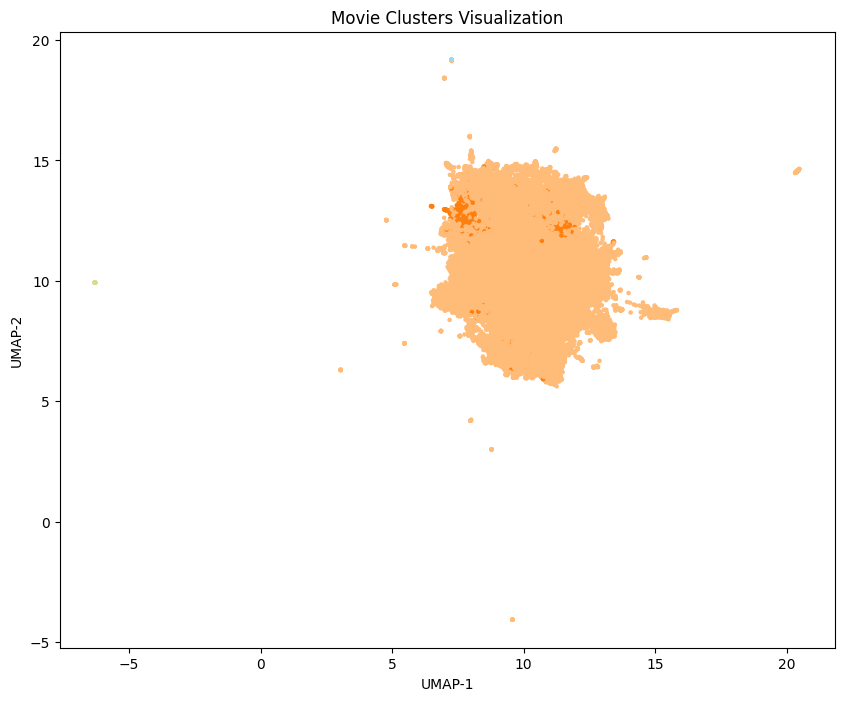

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=clusters,
    cmap="tab20",
    s=5
)

plt.title("Movie Clusters Visualization")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter(
    x=embedding_2d[:,0],
    y=embedding_2d[:,1],
    color=clusters.astype(str),
    title="Movie Clusters (UMAP)"
)

fig.show()

In [ ]:
for i in range(10):

    cluster_movies = movies[movies['cluster']==i]['title'].head(10)

    print("\nCluster", i)
    print(cluster_movies.tolist())


Cluster 0
[]

Cluster 1
[]

Cluster 2
[]

Cluster 3
['Days of Darkness', 'Days of Darkness', 'Days of Darkness', 'Days of Darkness', 'Days of Darkness', 'Days of Darkness', 'Days of Darkness', 'Days of Darkness']

Cluster 4
[]

Cluster 5
['The Hunted', 'New York Cop', 'Picture Bride', 'In the Realm of the Senses', 'The Next Karate Kid', 'Rising Sun', 'The Ballad of Narayama', 'Wife', 'Wife', 'Wife']

Cluster 6
['Toy Story', 'Jumanji', 'Grumpier Old Men', 'Waiting to Exhale', 'Father of the Bride Part II', 'Heat', 'Sabrina', 'Tom and Huck', 'Sudden Death', 'GoldenEye']

Cluster 7
[]

Cluster 8
[]

Cluster 9
[]


In [ ]:
def recommend(movie):
    movie_index = movies[movies['title']==movie].index[0]
    movie_cluster = movies.iloc[movie_index]['cluster']
    cluster_movies = movies[movies['cluster']==movie_cluster]
    cluster_indices = cluster_movies.index.tolist()

    similarity = cosine_similarity([X[movie_index]], X[cluster_indices])
    distances = similarity[0]

    movie_list = sorted(list(zip(cluster_indices, distances)), reverse=True, key=lambda x: x[1])[1:11]
    recs = movies.iloc[[i[0] for i in movie_list]]

    return recs[['title','poster_url','watch_url']].to_dict(orient='records')

In [ ]:
recommend("Love Story")

[{'title': 'The Barretts of Wimpole Street',
  'poster_url': 'https://picsum.photos/seed/8365/300/450',
  'watch_url': 'https://www.youtube.com/results?search_query=The+Barretts+of+Wimpole+Street+movie'},
 {'title': 'Flower Girl',
  'poster_url': 'https://picsum.photos/seed/38290/300/450',
  'watch_url': 'https://www.youtube.com/results?search_query=Flower+Girl+movie'},
 {'title': 'The Paper Chase',
  'poster_url': 'https://picsum.photos/seed/3608/300/450',
  'watch_url': 'https://www.youtube.com/results?search_query=The+Paper+Chase+movie'},
 {'title': "The Chinese Botanist's Daughters",
  'poster_url': 'https://picsum.photos/seed/33660/300/450',
  'watch_url': "https://www.youtube.com/results?search_query=The+Chinese+Botanist's+Daughters+movie"},
 {'title': 'Breaking Up',
  'poster_url': 'https://picsum.photos/seed/5898/300/450',
  'watch_url': 'https://www.youtube.com/results?search_query=Breaking+Up+movie'},
 {'title': 'One Night of Love',
  'poster_url': 'https://picsum.photos/seed

In [ ]:
import pickle
import numpy as np

# --------- Save embeddings ----------
np.save("/content/drive/MyDrive/movies_embeddings.npy", embeddings)

# --------- Save clustering model ----------
with open("/content/drive/MyDrive/dpmm_model.pkl", "wb") as f:
    pickle.dump(dpmm, f)

# --------- Save movie dataframe ----------
movies.to_csv("/content/drive/MyDrive/movies_with_urls.csv", index=False)

In [ ]:
model.save("/content/drive/MyDrive/sentence_transformer_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("/content/drive/MyDrive/sentence_transformer_model")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
import numpy as np


In [ ]:
# Load embeddings
embeddings = np.load("/content/drive/MyDrive/movies_embeddings.npy")

# Load clustering model
with open("/content/drive/MyDrive/dpmm_model.pkl", "rb") as f:
    dpmm = pickle.load(f)

# Load movies dataframe
import pandas as pd
movies = pd.read_csv("/content/drive/MyDrive/movies_with_urls.csv")

# Reload SentenceTransformer
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("/content/drive/MyDrive/sentence_transformer_model")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import pickle

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# -------- Load saved files --------
movies = pd.read_csv("/content/drive/MyDrive/movies_with_urls.csv")
embeddings = np.load("/content/drive/MyDrive/movies_embeddings.npy")

with open("/content/drive/MyDrive/dpmm_model.pkl", "rb") as f:
    dpmm = pickle.load(f)

model = SentenceTransformer("/content/drive/MyDrive/sentence_transformer_model")

# -------- PCA for dimensionality reduction --------
pca = PCA(n_components=100)
X = pca.fit_transform(embeddings)

# -------- Movie Search Function --------
def search_movies(query, top_n=6):

    # Encode query
    query_emb = model.encode([query])

    # Normalize
    query_emb = query_emb / np.linalg.norm(query_emb)

    # Apply SAME PCA
    query_emb = pca.transform(query_emb)

    # Cosine similarity
    sim = cosine_similarity(query_emb, X)[0]

    # Top results
    top_idx = sim.argsort()[-top_n:][::-1]

    results = []

    for i in top_idx:
        row = movies.iloc[i]
        results.append({
            "title": row['title'],
            "poster": row['poster_url'],
            "link": row['watch_url']
        })

    return results


# -------- UI Rendering --------
def gradio_search(query):

    results = search_movies(query)

    html = """
    <div style="
        display:flex;
        flex-wrap:wrap;
        justify-content:center;
        gap:20px;
        ">
    """

    for r in results:

        html += f"""
        <div style="
            width:200px;
            background:#111;
            padding:10px;
            border-radius:10px;
            text-align:center;
            color:white;
            font-family:Arial;
            box-shadow:0 4px 10px rgba(0,0,0,0.5);
        ">

        <img src="{r['poster']}" width="180"
        style="border-radius:8px">

        <h3 style="margin:10px 0;">
        <b>{r['title']}</b>
        </h3>

        <a href="{r['link']}" target="_blank"
        style="
            display:inline-block;
            background:#ff0000;
            color:white;
            padding:8px 12px;
            border-radius:6px;
            text-decoration:none;
            font-weight:bold;
        ">
        ▶ Watch on YouTube
        </a>

        </div>
        """

    html += "</div>"

    return html


# -------- Gradio Interface --------
iface = gr.Interface(
    fn=gradio_search,
    inputs=gr.Textbox(
        label="🔎 Search Movie",
        placeholder="Type movie like: Batman, Spider Man..."
    ),
    outputs=gr.HTML(),
    title="🎬 AI Movie Search Engine",
    description="Search movies and watch trailers on YouTube"
)

iface.launch(share=True, debug=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://48bd99a3c1bc0d41ca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
